# IMPLEMENTANDO AS BIBLIOTECAS

In [24]:
# IMPLEMENTANDO AS BIBLIOTECAS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# UPLOAD DO DATASET

In [25]:
# FAZENDO UPLOAD DO DATASET
from google.colab import files

uploaded = files.upload()

Saving IRIS.csv to IRIS (2).csv


# LENDO OS DADOS DO DATASET

In [26]:
# LENDO OS DADOS DO DATASET
df = pd.read_csv('IRIS.csv')

df.sample(20) # ESSA LINHA ESTÁ PEGANDO 20 LINHAS ALEATÓRIAS NO DATASET

,sepal_length,sepal_width,petal_length,petal_width,species
126,6.2,2.8,4.8,1.8,Iris-virginica
65,6.7,3.1,4.4,1.4,Iris-versicolor
10,5.4,3.7,1.5,0.2,Iris-setosa
83,6.0,2.7,5.1,1.6,Iris-versicolor
45,4.8,3.0,1.4,0.3,Iris-setosa
77,6.7,3.0,5.0,1.7,Iris-versicolor
38,4.4,3.0,1.3,0.2,Iris-setosa
23,5.1,3.3,1.7,0.5,Iris-setosa
68,6.2,2.2,4.5,1.5,Iris-versicolor
94,5.6,2.7,4.2,1.3,Iris-versicolor


In [27]:
# ALGUMAS INFORMAÇÕES REFERENTE AOS DADOS DO DATASET
print("Quantidade de registros:")
print(df.shape)

print("\nInformações:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

Quantidade de registros:
(150, 5)

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Valores nulos:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [28]:
print("Estatísticas Descritivas")
display(df.describe())

Estatísticas Descritivas


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# SEPARAÇÕES DAS VARÍAVEIS

In [29]:
# SEPARAÇÕES DAS VARÍAVEIS
X = df.drop(columns=['species'])

if 'Id' in X.columns:
    X = X.drop(columns=['Id'])

y = df['species']

# DIVISÃO TREINO/TESTE

In [30]:
# DIVISÃO TREINO/TESTE
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print("Treino:",X_train.shape)
print("Teste:",X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


# PADRONIZAÇÃO DOS DADOS

In [31]:
# PADRONIZAÇÃO DOS DADOS (MELHOR QUANDO USAMOS KNN)
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# TREINANDO O KNN

In [32]:
# TREINANDO O KNN
knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

y_pred_knn=knn.predict(X_test_scaled)

In [33]:
# TREINANDO E GERANDO O ARQUIVO TREINADO
from sklearn.neighbors import KNeighborsClassifier
import joblib

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# salvar modelo
joblib.dump(knn, 'modelo_knn.pkl')

['modelo_knn.pkl']

# MÉTRICAS DO KNN

In [34]:
# MÉTRICAS DO KNN
acc_knn=accuracy_score(y_test,y_pred_knn)
prec_knn=precision_score(y_test,y_pred_knn,average='weighted')
rec_knn=recall_score(y_test,y_pred_knn,average='weighted')
f1_knn=f1_score(y_test,y_pred_knn,average='weighted')

print("=== KNN ===")
print("Acurácia:",acc_knn)
print("Precisão:",prec_knn)
print("Recall:",rec_knn)
print("F1-Score:",f1_knn)

print("\nRelatório:")
print(classification_report(y_test,y_pred_knn))

=== KNN ===
Acurácia: 0.9333333333333333
Precisão: 0.9444444444444445
Recall: 0.9333333333333333
F1-Score: 0.9326599326599326

Relatório:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



# MATRIZ DE CONFUSÃO (KNN)

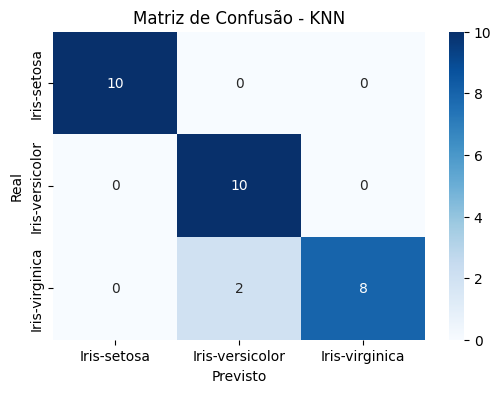

In [35]:
# MATRIZ DE CONFUSÃO (KNN)
cm_knn=confusion_matrix(y_test,y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(
cm_knn,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=knn.classes_,
yticklabels=knn.classes_
)

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# TREINANDO O RANDOM FOREST

In [36]:
# TREINANDO O RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [37]:
# GERANDO ARQUIVO TREINADO RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
import joblib

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# salvar modelo
joblib.dump(rf, 'modelo_random_forest.pkl')

['modelo_random_forest.pkl']

# MÉTRICAS RANDOM FOREST

In [38]:
# MÉTRICAS RANDOM FOREST
acc_rf=accuracy_score(y_test,y_pred_rf)
prec_rf=precision_score(y_test,y_pred_rf,average='weighted')
rec_rf=recall_score(y_test,y_pred_rf,average='weighted')
f1_rf=f1_score(y_test,y_pred_rf,average='weighted')

print("=== RANDOM FOREST ===")
print("Acurácia:",acc_rf)
print("Precisão:",prec_rf)
print("Recall:",rec_rf)
print("F1-Score:",f1_rf)

print("\nRelatório:")
print(classification_report(y_test,y_pred_rf))

=== RANDOM FOREST ===
Acurácia: 0.9
Precisão: 0.9023569023569024
Recall: 0.9
F1-Score: 0.8997493734335839

Relatório:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



# MATRIZ DE CONFUSÃO (RANDOM FOREST)

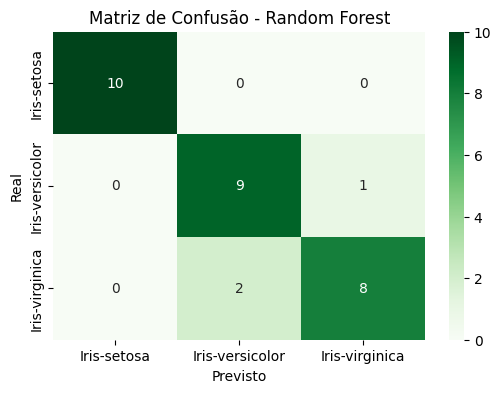

In [39]:
# MATRIZ DE CONFUSÃO (RANDOM FOREST)
cm_rf=confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
cm_rf,
annot=True,
fmt='d',
cmap='Greens',
xticklabels=rf.classes_,
yticklabels=rf.classes_
)

plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# COMPARAÇÃO DAS MÉTRICAS

In [40]:
# COMPARAÇÃO DAS MÉTRICAS
metricas=pd.DataFrame({
'Modelo': ['KNN','Random Forest'],
'Acurácia': [acc_knn,acc_rf],
'Precisão': [prec_knn,prec_rf],
'Recall': [rec_knn,rec_rf],
'F1-Score': [f1_knn,f1_rf]
})

metricas

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,KNN,0.933333,0.944444,0.933333,0.932660
1,Random Forest,0.900000,0.902357,0.900000,0.899749


# GRÁFICO COMPARATIVO

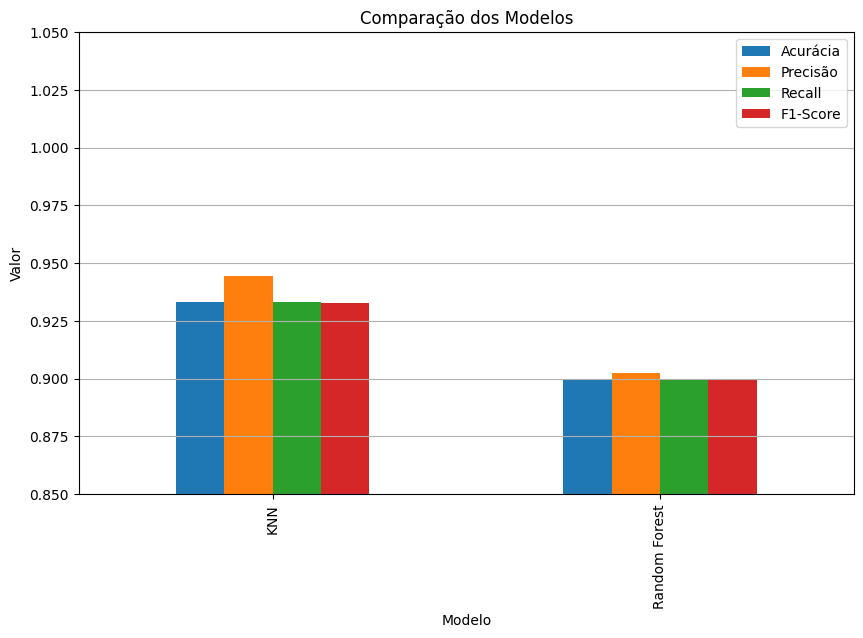

In [41]:
# GRÁFICO COMPARATIVO
metricas_plot=metricas.set_index('Modelo')

metricas_plot.plot(
kind='bar',
figsize=(10,6)
)

plt.title('Comparação dos Modelos')
plt.ylabel('Valor')
plt.ylim(0.85,1.05)
plt.grid(axis='y')
plt.show()


# QUAL SERIA O MELHOR MÉTODO?

In [42]:
# DESCOBRIR O MELHOR MODELO
if acc_rf > acc_knn:
    melhor = "Random Forest"
elif acc_knn > acc_rf:
    melhor = "KNN"
else:
    melhor = "Empate"

print("Melhor modelo:", melhor)

Melhor modelo: KNN
